# Piezo Triangle Scan - Beam Position Analysis

Loads a CSV produced by `piezo_triangle_scan.py` (columns: sample, timestamp,
voltage_setpoint_V, voltage_readback_V, centroid_x_um, centroid_y_um,
peak_x_um, peak_y_um, peak_intensity_counts, total_power_mW) and plots:

- voltage and beam centroid vs. sample (time series)
- **X displacement vs. piezo voltage** (the mirror's transfer function),
  colored by sample order so any hysteresis between the rising and falling
  ramps of the triangle wave is visible
- a linear fit to estimate the X-axis sensitivity in um/V


In [15]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

DATA_DIR = "."

# pick the most recent scan CSV by default; override CSV_PATH to load a specific file
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "piezo_scan_*.csv")))
CSV_PATH = csv_files[-1] if csv_files else None
print("Available scans:", [os.path.basename(f) for f in csv_files])
print("Loading:", CSV_PATH)

Available scans: ['piezo_scan_20260625_153938.csv', 'piezo_scan_20260625_160026.csv', 'piezo_scan_20260625_164729.csv']
Loading: .\piezo_scan_20260625_164729.csv


In [16]:
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df.head()

,sample,timestamp,voltage_setpoint_V,voltage_readback_V,centroid_x_um,centroid_y_um,peak_x_um,peak_y_um,peak_intensity_counts,total_power_mW
0,0,2026-06-25 16:40:44.101348,0.00,0.00,-642.619418,98.886875,-348.299990,-1425.449958,255.0,0.000834
1,1,2026-06-25 16:40:46.154892,3.75,3.77,-642.487930,101.347354,-348.299990,-1425.449958,255.0,0.000834
2,2,2026-06-25 16:40:47.879439,7.50,3.77,-642.742638,104.571173,-354.749990,-1425.449958,255.0,0.000834
3,3,2026-06-25 16:40:49.386505,11.25,11.28,-642.502496,107.752081,-754.649978,-1393.199959,255.0,0.000834
4,4,2026-06-25 16:40:50.940284,15.00,15.04,-642.106851,111.203445,-670.799980,-1393.199959,255.0,0.000834


## Voltage and beam centroid vs. sample

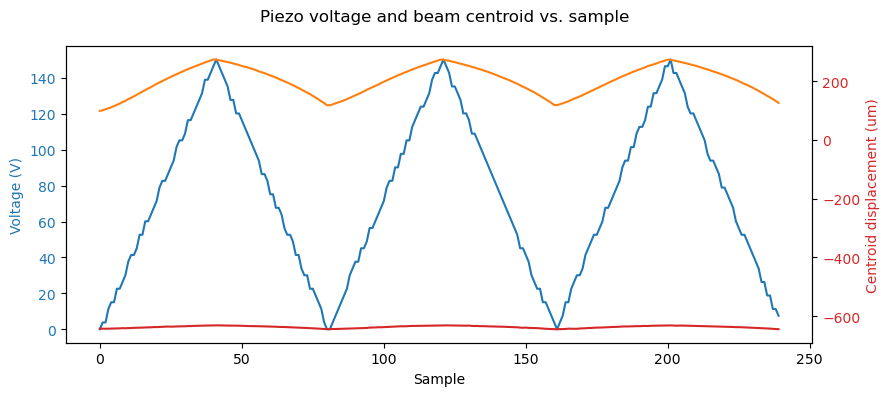

In [17]:
fig, ax_v = plt.subplots(figsize=(9, 4))
ax_v.plot(df["sample"], df["voltage_readback_V"], color="tab:blue", label="Piezo voltage (readback)")
ax_v.set_xlabel("Sample")
ax_v.set_ylabel("Voltage (V)", color="tab:blue")
ax_v.tick_params(axis="y", labelcolor="tab:blue")

ax_p = ax_v.twinx()
ax_p.plot(df["sample"], df["centroid_x_um"], color="tab:red", label="Centroid X")
ax_p.plot(df["sample"], df["centroid_y_um"], color="tab:orange", label="Centroid Y")
ax_p.set_ylabel("Centroid displacement (um)", color="tab:red")
ax_p.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("Piezo voltage and beam centroid vs. sample")
fig.tight_layout()
plt.show()

## X displacement vs. voltage

Each point is colored by sample index (time order), so the rising and
falling legs of the triangle wave are distinguishable - a gap between
the two colors at the same voltage indicates piezo hysteresis.

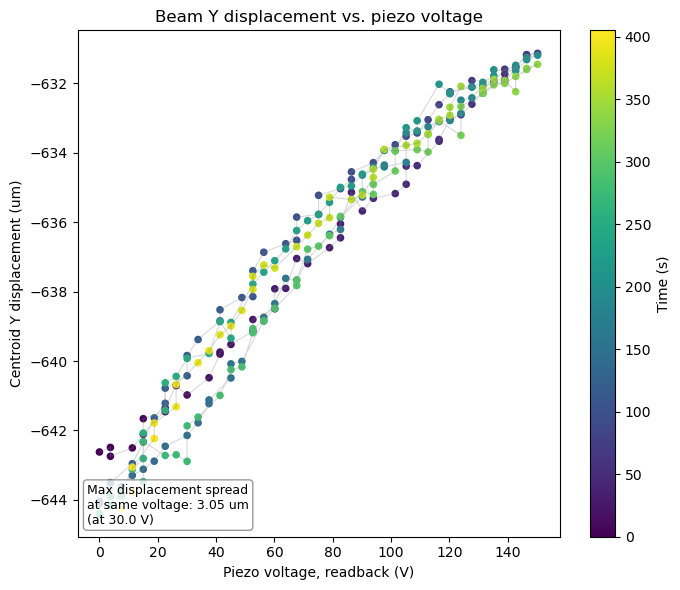

Max displacement spread at the same voltage: 3.048 um, at setpoint 30.00 V


In [20]:
elapsed_s = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["voltage_readback_V"], df["centroid_x_um"],
                 c=elapsed_s, cmap="viridis", s=20)
ax.plot(df["voltage_readback_V"], df["centroid_x_um"], "-", color="gray", alpha=0.3, linewidth=0.8)

ax.set_xlabel("Piezo voltage, readback (V)")
ax.set_ylabel("Centroid Y displacement (um)")
ax.set_title("Beam Y displacement vs. piezo voltage")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time (s)")

# max spread in X displacement among samples that share the same voltage setpoint --
# this is the hysteresis gap between the rising and falling legs of the triangle wave
spread_by_voltage = df.groupby("voltage_setpoint_V")["centroid_x_um"].agg(lambda s: s.max() - s.min())
max_spread = spread_by_voltage.max()
max_spread_voltage = spread_by_voltage.idxmax()

ax.annotate(
    f"Max displacement spread\nat same voltage: {max_spread:.2f} um\n(at {max_spread_voltage:.1f} V)",
    xy=(0.02, 0.02), xycoords="axes fraction", va="bottom", ha="left",
    fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
)

fig.tight_layout()
plt.show()

print(f"Max displacement spread at the same voltage: {max_spread:.3f} um, at setpoint {max_spread_voltage:.2f} V")

## Linear fit: X-axis sensitivity (um/V)

X sensitivity: 0.088 um/V
Intercept: -643.425 um


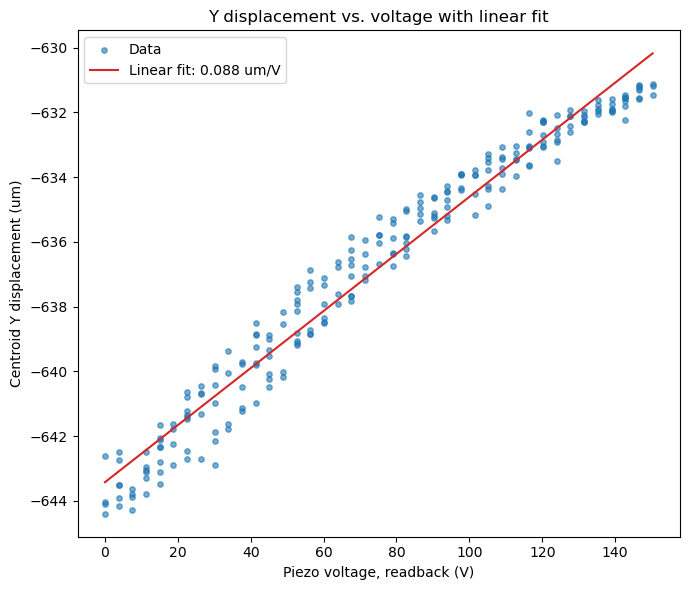

In [21]:
slope, intercept = np.polyfit(df["voltage_readback_V"], df["centroid_x_um"], 1)
print(f"X sensitivity: {slope:.3f} um/V")
print(f"Intercept: {intercept:.3f} um")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["voltage_readback_V"], df["centroid_x_um"], s=15, alpha=0.6, label="Data")

v_fit = np.linspace(df["voltage_readback_V"].min(), df["voltage_readback_V"].max(), 200)
ax.plot(v_fit, slope * v_fit + intercept, color="tab:red",
        label=f"Linear fit: {slope:.3f} um/V")

ax.set_xlabel("Piezo voltage, readback (V)")
ax.set_ylabel("Centroid Y displacement (um)")
ax.set_title("Y displacement vs. voltage with linear fit")
ax.legend()
fig.tight_layout()
plt.show()